In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import os
import sys
import gc
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
import torch

main_folder = "../.."
sys.path.insert(0, os.path.join(main_folder))

from src.config import EXP_CONFIGS
from src.inference_feedback import (
    extract_aux_oof_to_csv,
    sweep_thresholds, uncertainty_band, assign_reliability,
    load_model,
    run_batch,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

TARGET     = "Pawpularity"
IMG_FOLDER = os.path.join(main_folder, "data", "train")
CSV_PATH   = os.path.join(main_folder, "data", "train.csv")
df         = pd.read_csv(CSV_PATH)
AUX_TASKS  = ["Eyes","Face","Occlusion", "Blur",
                             "Subject Focus","Action","Accessory",
                             "Near", "Group","Collage","Human", "Info"]
SWIN_GRID  = (12, 12)

# exp19: standard BCE aux heads
out_dir_exp19 = os.path.join(main_folder, "outputs", "extra",
                             "exp19_swin_384_strong_MSELoss_All12_Aux_StrongHead_fixDupOcclusion")

cfg_exp19 = EXP_CONFIGS["exp15_aux_brisque"].copy()
cfg_exp19["img_size"] = 384
cfg_exp19["name"] = "exp19_swin_384_strong_MSELoss_All12_Aux_StrongHead_fixDupOcclusion"
cfg_exp19["loss"] = "mse"
cfg_exp19["head_type"] = "mlp"
cfg_exp19["aux_tasks"] = []
cfg_exp19["binary_aux_tasks"]   = ["Eyes","Face","Occlusion", "Blur",
                             "Subject Focus","Action","Accessory",
                             "Near", "Group","Collage","Human", "Info"]  # all 12 binary aux tasks
cfg_exp19["aux_loss_weights"]   = {
    "Face":      0.1,
    "Eyes":      0.1,
    "Occlusion": 0.1,
    "Blur":      0.1,
    "Subject Focus": 0.1,
    "Action": 0.1,
    "Accessory": 0.1,
    "Group": 0.1,
    "Collage": 0.1,
    "Human": 0.1,
    "Info": 0.1,
    "Near": 0.1
}
cfg_exp19["use_saliency"] = False

ACTIVE_CFG = cfg_exp19
ACTIVE_DIR = out_dir_exp19


Device: cuda


In [22]:

# To create the aux head with the probabilities for each record and each aux head and save it to a CSV file
aux_df = extract_aux_oof_to_csv(
    out_dir=ACTIVE_DIR,
    df=df,
    img_folder=IMG_FOLDER,
    cfg=ACTIVE_CFG,
    device=device,
)

Loading existing: ../../outputs/extra/exp19_swin_384_strong_MSELoss_All12_Aux_StrongHead_fixDupOcclusion/oof_detail_aux.csv


In [23]:
aux_df.head()

,Id,fold,ytrue,Eyes_true,Eyes_prob,Eyes_pred_05,Face_true,Face_prob,Face_pred_05,Occlusion_true,...,Group_pred_05,Collage_true,Collage_prob,Collage_pred_05,Human_true,Human_prob,Human_pred_05,Info_true,Info_prob,Info_pred_05
0,0007de18844b0dbbb5e1f607da0606e0,1,63.0,1,0.800557,1,1,0.923141,1,0,...,0,0,0.067400,0,0,0.272856,0,0,0.081145,0
1,0018df346ac9c1d8413cfcc888ca8246,1,15.0,1,0.735342,1,1,0.900173,1,0,...,0,0,0.045323,0,0,0.210455,0,0,0.062315,0
2,0042bc5bada6d1cf8951f8f9f0d399fa,1,53.0,1,0.750277,1,1,0.911344,1,0,...,0,0,0.042449,0,0,0.157305,0,0,0.058219,0
3,005017716086b8d5e118dd9fe26459b1,1,28.0,1,0.858519,1,1,0.952724,1,0,...,0,0,0.030480,0,0,0.152466,0,0,0.044842,0
4,00630b1262efe301cb15a3b2022ba744,1,18.0,1,0.771668,1,1,0.912375,1,0,...,0,0,0.039415,0,0,0.117797,0,0,0.047521,0


In [24]:
aux_df.columns

Index(['Id', 'fold', 'ytrue', 'Eyes_true', 'Eyes_prob', 'Eyes_pred_05',
       'Face_true', 'Face_prob', 'Face_pred_05', 'Occlusion_true',
       'Occlusion_prob', 'Occlusion_pred_05', 'Blur_true', 'Blur_prob',
       'Blur_pred_05', 'Subject Focus_true', 'Subject Focus_prob',
       'Subject Focus_pred_05', 'Action_true', 'Action_prob', 'Action_pred_05',
       'Accessory_true', 'Accessory_prob', 'Accessory_pred_05', 'Near_true',
       'Near_prob', 'Near_pred_05', 'Group_true', 'Group_prob',
       'Group_pred_05', 'Collage_true', 'Collage_prob', 'Collage_pred_05',
       'Human_true', 'Human_prob', 'Human_pred_05', 'Info_true', 'Info_prob',
       'Info_pred_05'],
      dtype='object')

Raw OOF calibration summary for all 12 auxiliary heads:


,task,n,n_positive,n_negative,positive_rate,raw_prob_min,raw_prob_max,raw_brier,raw_ece
0,Eyes,9912,7658,2254,0.7726,0.3084,0.9246,0.1577,0.0683
1,Near,9912,8540,1372,0.8616,0.2667,0.9805,0.1019,0.0641
2,Face,9912,8960,952,0.9040,0.5008,0.9733,0.0785,0.0559
3,Occlusion,9912,1705,8207,0.1720,0.0638,0.4775,0.1279,0.0557
4,Human,9912,1648,8264,0.1663,0.0513,0.5021,0.1228,0.0472
5,Group,9912,1282,8630,0.1293,0.0403,0.6485,0.1015,0.0450
6,Info,9912,607,9305,0.0612,0.0222,0.3674,0.0538,0.0232
7,Accessory,9912,672,9240,0.0678,0.0327,0.1572,0.0620,0.0143
8,Blur,9912,698,9214,0.0704,0.0287,0.1250,0.0651,0.0092
9,Collage,9912,492,9420,0.0496,0.0181,0.2523,0.0444,0.0088


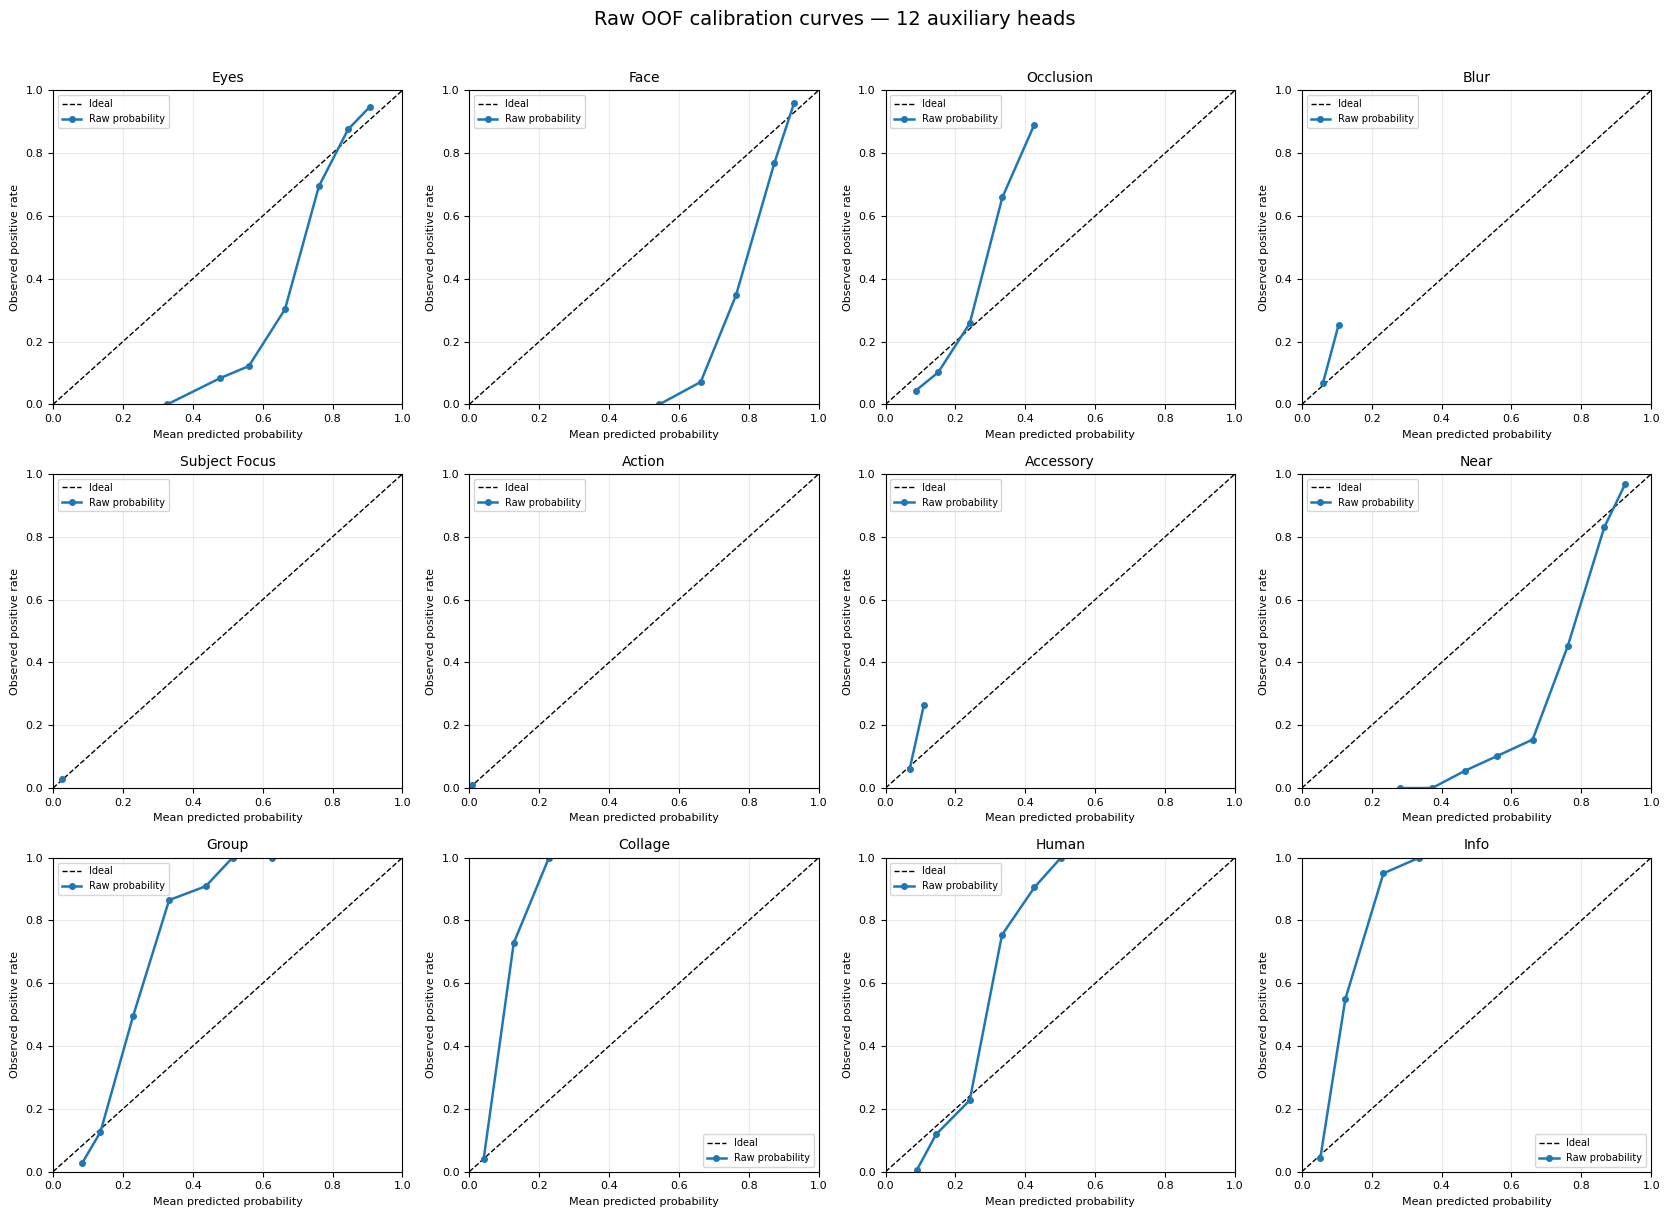

In [25]:
# ============================================================
# SECTION 2 — STEP 2A: Raw probability calibration diagnosis
#
#  feedback addressed:
# "Evaluate the calibration status of each label using:
#  1. Calibration curve
#  2. Brier score
#  3. Expected Calibration Error (ECE)"
#
# Uses:
# - all 12 auxiliary heads
# - all pooled OOF records
# - raw sigmoid probabilities only
#
# Does NOT fit any calibration method yet.
# Does NOT calculate F1 thresholds yet.
# Does NOT modify inference_feedback.py.
# ============================================================

from src.aux_calibration import (
    diagnose_raw_oof_calibration,
    plot_calibration_curves,
)

# All 12 heads are analysed first.
# We will decide later which labels are usable for user-facing feedback.
CALIBRATION_TASKS = AUX_TASKS.copy()

raw_calibration_summary, raw_bin_tables = (
    diagnose_raw_oof_calibration(
        aux_df=aux_df,
        aux_tasks=CALIBRATION_TASKS,
        n_bins=10,
    )
)

# Sort worst-to-best by raw ECE only for inspection.
# This is not a final decision rule because ECE can be unstable for
# extremely rare labels; the calibration curve and Brier score matter too.
raw_calibration_summary = raw_calibration_summary.sort_values(
    "raw_ece",
    ascending=False,
).reset_index(drop=True)

print("Raw OOF calibration summary for all 12 auxiliary heads:")
display(raw_calibration_summary.round(4))

plot_calibration_curves(
    bin_tables=raw_bin_tables,
    aux_tasks=CALIBRATION_TASKS,
    title="Raw OOF calibration curves — 12 auxiliary heads",
    n_cols=4,
    method_label="Raw probability",
)

> Observed postive rate = True positive rate

The reliability diagrams show that the raw auxiliary-head probabilities are not consistently calibrated. Eyes, Face, and Near are generally overconfident, because their observed positive rates fall below their mean predicted probabilities over much of the occupied probability range. In contrast, Group, Collage, Human, and Info are generally underconfident, because their observed positive rates lie above their mean predicted probabilities. Occlusion shows mixed calibration behavior across its probability range. Each point represents one probability bin: the x-axis is the bin’s mean predicted probability, the y-axis is its observed positive-label rate, and perfect calibration lies on the dashed diagonal.

In [ ]:
# Cross-fit Platt and isotonic calibration for all auxiliary feedback heads.

import numpy as np
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression


def crossfit_calibration(aux_df, tasks, fold_col="fold"):
    out = aux_df.copy()
    folds = sorted(out[fold_col].dropna().unique())

    for task in tasks:
        y_col = f"{task}_true"
        p_col = f"{task}_prob"

        out[f"{task}_prob_platt_cf"] = np.nan
        out[f"{task}_prob_isotonic_cf"] = np.nan

        for holdout_fold in folds:
            train = out[out[fold_col] != holdout_fold][[y_col, p_col]].dropna()
            test_idx = out.index[
                (out[fold_col] == holdout_fold)
                & out[y_col].notna()
                & out[p_col].notna()
            ]

            if len(test_idx) == 0 or train[y_col].nunique() < 2:
                continue

            x_train = train[p_col].clip(1e-6, 1 - 1e-6).to_numpy()
            y_train = train[y_col].astype(int).to_numpy()
            x_test = out.loc[test_idx, p_col].clip(1e-6, 1 - 1e-6).to_numpy()

            platt = LogisticRegression(solver="lbfgs")
            platt.fit(x_train.reshape(-1, 1), y_train)
            out.loc[test_idx, f"{task}_prob_platt_cf"] = (
                platt.predict_proba(x_test.reshape(-1, 1))[:, 1]
            )

            isotonic = IsotonicRegression(
                y_min=0.0,
                y_max=1.0,
                out_of_bounds="clip",
            )
            isotonic.fit(x_train, y_train)
            out.loc[test_idx, f"{task}_prob_isotonic_cf"] = isotonic.predict(x_test)

    return out


aux_cal_df = crossfit_calibration(
    aux_df=aux_df,
    tasks=CALIBRATION_TASKS,
    fold_col="fold", 
)

print("Created cross-fitted Platt and isotonic probabilities for all feedback heads.")

Created cross-fitted Platt and isotonic probabilities for all feedback heads.


In [ ]:
# Section 2 Compare raw vs cross-fitted calibrated probabilities for feedback heads.

from sklearn.metrics import brier_score_loss


def calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true, dtype=float)
    y_prob = np.asarray(y_prob, dtype=float)

    edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, edges[1:-1], right=True)

    ece = 0.0

    for bin_id in range(n_bins):
        mask = bin_ids == bin_id

        if mask.sum() == 0:
            continue

        ece += (
            mask.mean()
            * abs(y_prob[mask].mean() - y_true[mask].mean())
        )

    return ece


rows = []

for task in CALIBRATION_TASKS:
    for method, prob_col in {
        "raw": f"{task}_prob",
        "platt_cf": f"{task}_prob_platt_cf",
        "isotonic_cf": f"{task}_prob_isotonic_cf",
    }.items():
        valid = aux_cal_df[[f"{task}_true", prob_col]].dropna()

        rows.append({
            "task": task,
            "method": method,
            "n": len(valid),
            "brier": brier_score_loss(valid[f"{task}_true"], valid[prob_col]),
            "ece_10": calibration_error(
                valid[f"{task}_true"],
                valid[prob_col],
                n_bins=10,
            ),
        })

calibration_results = (
    pd.DataFrame(rows)
    .sort_values(["task", "brier", "ece_10"])
    .reset_index(drop=True)
)

display(calibration_results)

,task,method,n,brier,ece_10
0,Accessory,raw,9912,0.062002,0.014349
1,Accessory,platt_cf,9912,0.062760,0.000598
2,Accessory,isotonic_cf,9912,0.063776,0.016334
3,Action,platt_cf,9912,0.009890,0.000072
4,Action,isotonic_cf,9912,0.009895,0.000188
5,Action,raw,9912,0.009895,0.000921
6,Blur,raw,9912,0.065077,0.009201
7,Blur,platt_cf,9912,0.065421,0.000004
8,Blur,isotonic_cf,9912,0.065927,0.007189
9,Collage,isotonic_cf,9912,0.038594,0.004781


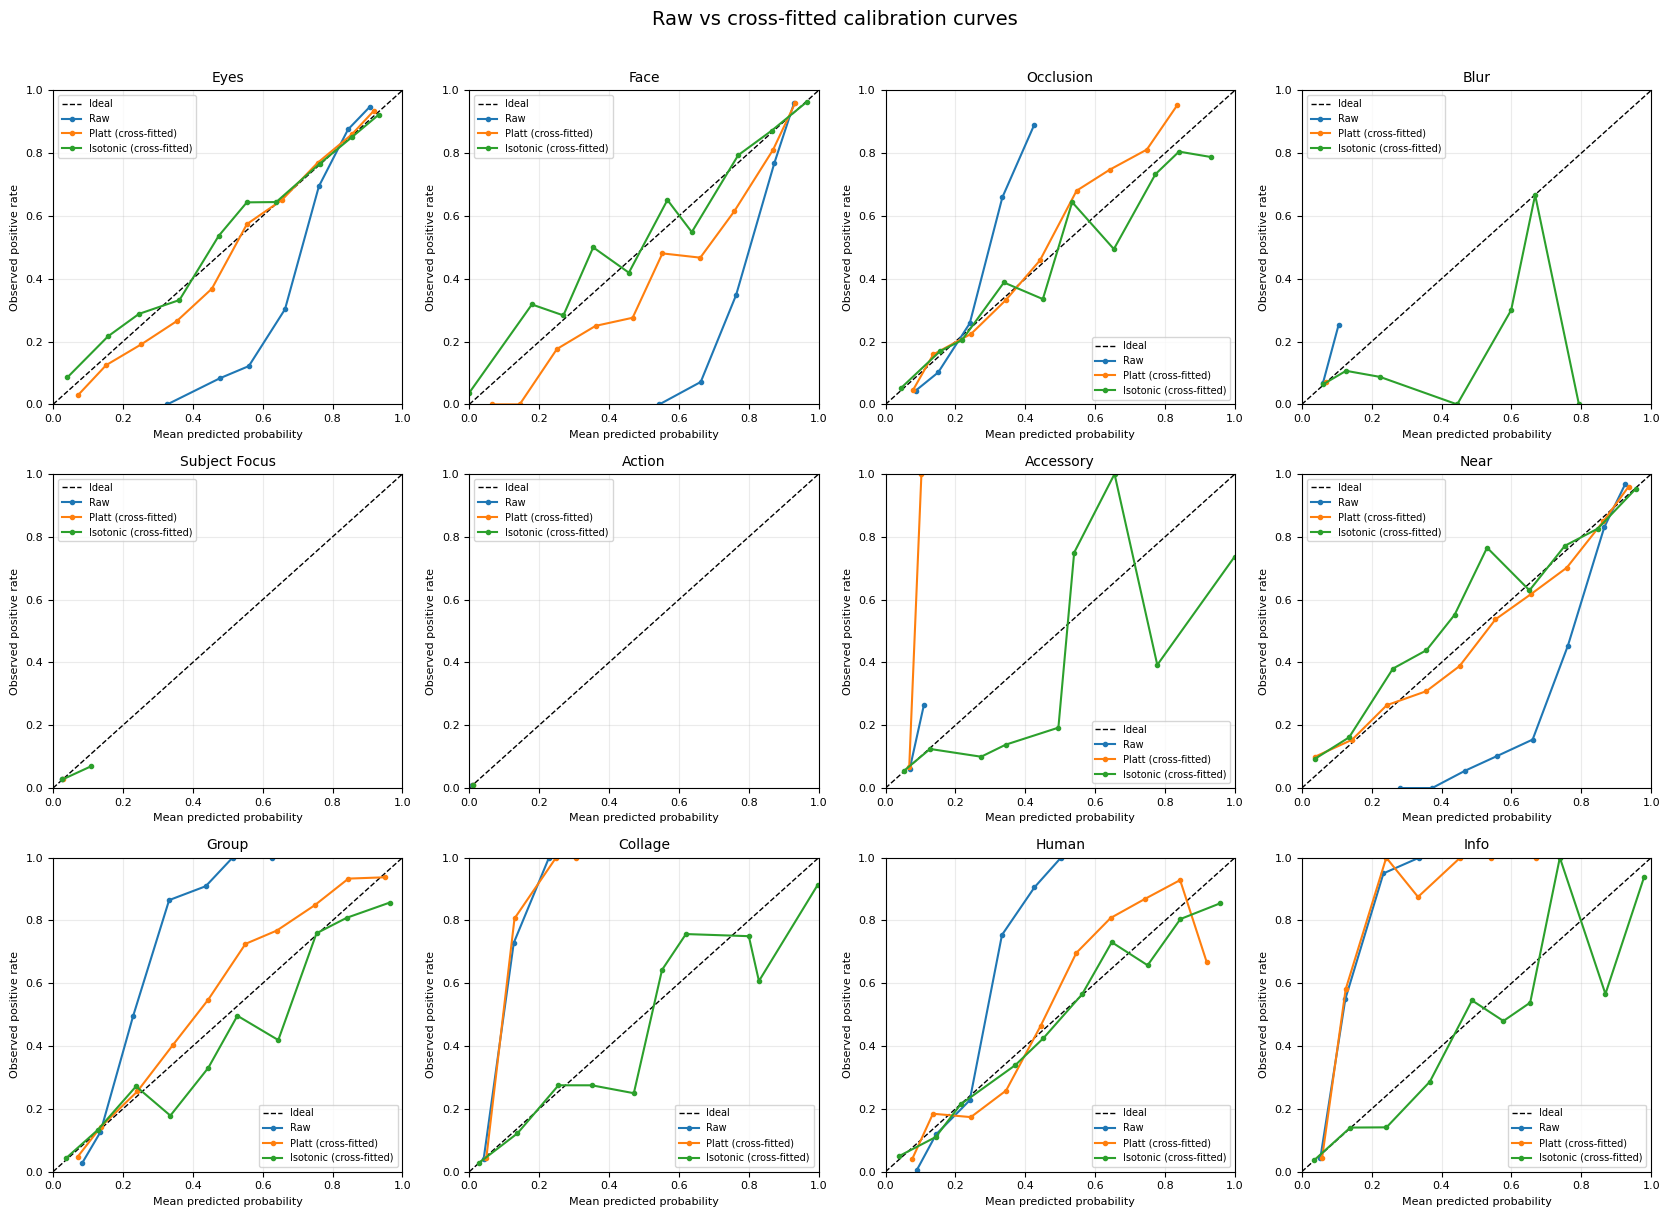

In [28]:
# SECTION 2 Plot raw vs Platt vs isotonic calibration curves.
# 

from src.aux_calibration import (
    probability_metrics,
    plot_calibration_comparison,
)


bin_tables_by_task = {}

for task in CALIBRATION_TASKS:
    y_true = aux_cal_df[f"{task}_true"]

    bin_tables_by_task[task] = {
        "raw": probability_metrics(
            y_true=y_true,
            y_prob=aux_cal_df[f"{task}_prob"],
            n_bins=10,
        )[1],
        "platt": probability_metrics(
            y_true=y_true,
            y_prob=aux_cal_df[f"{task}_prob_platt_cf"],
            n_bins=10,
        )[1],
        "isotonic": probability_metrics(
            y_true=y_true,
            y_prob=aux_cal_df[f"{task}_prob_isotonic_cf"],
            n_bins=10,
        )[1],
    }


plot_calibration_comparison(
    bin_tables_by_task=bin_tables_by_task,
    aux_tasks=CALIBRATION_TASKS,
)

Cross-fitted calibration improved probability quality for most auxiliary heads. Platt scaling was selected for Eyes, Group, and Near, while isotonic regression was selected for Face, Occlusion, Collage, Human, and Info. For each of these heads, the selected calibrated probability reduced both Brier score and ECE relative to the raw probability, and the corresponding reliability curves moved closer to the ideal diagonal. Raw probabilities were retained for Blur, Accessory, Subject Focus, and Action because neither calibrated alternative improved both Brier score and ECE simultaneously; in several cases calibration reduced ECE but slightly worsened Brier score.

In [29]:
# SECTION 2 , Select final calibrated probability per feedback head.
# Use selected probabilities only in later threshold and display-feedback analysis.

SELECTED_METHODS = {
    "Accessory": "raw",
    "Action": "raw",
    "Blur": "raw",
    "Collage": "isotonic_cf",
    "Eyes": "platt_cf",
    "Face": "isotonic_cf",
    "Group": "platt_cf",
    "Human": "isotonic_cf",
    "Info": "isotonic_cf",
    "Near": "platt_cf",
    "Occlusion": "isotonic_cf",
    "Subject Focus": "raw",
}

aux_selected_df = aux_cal_df.copy()

for task, method in SELECTED_METHODS.items():
    source_col = (
        f"{task}_prob"
        if method == "raw"
        else f"{task}_prob_{method}"
    )

    aux_selected_df[f"{task}_prob_selected"] = (
        aux_selected_df[source_col]
    )

selection_rows = []

for task, method in SELECTED_METHODS.items():
    method_name_in_table = method

    selected_metrics = calibration_results[
        (calibration_results["task"] == task)
        & (calibration_results["method"] == method_name_in_table)
    ].iloc[0]

    raw_metrics = calibration_results[
        (calibration_results["task"] == task)
        & (calibration_results["method"] == "raw")
    ].iloc[0]

    selection_rows.append({
        "task": task,
        "selected_method": method,
        "selected_probability_column": f"{task}_prob_selected",
        "raw_brier": raw_metrics["brier"],
        "selected_brier": selected_metrics["brier"],
        "raw_ece_10": raw_metrics["ece_10"],
        "selected_ece_10": selected_metrics["ece_10"],
    })

calibration_selection_df = (
    pd.DataFrame(selection_rows)
    .sort_values("task")
    .reset_index(drop=True)
)

display(calibration_selection_df.round(6))

,task,selected_method,selected_probability_column,raw_brier,selected_brier,raw_ece_10,selected_ece_10
0,Accessory,raw,Accessory_prob_selected,0.062002,0.062002,0.014349,0.014349
1,Action,raw,Action_prob_selected,0.009895,0.009895,0.000921,0.000921
2,Blur,raw,Blur_prob_selected,0.065077,0.065077,0.009201,0.009201
3,Collage,isotonic_cf,Collage_prob_selected,0.044437,0.038594,0.008761,0.004781
4,Eyes,platt_cf,Eyes_prob_selected,0.157659,0.145635,0.068291,0.013674
5,Face,isotonic_cf,Face_prob_selected,0.078531,0.070479,0.055906,0.010490
6,Group,platt_cf,Group_prob_selected,0.101451,0.094351,0.045021,0.021288
7,Human,isotonic_cf,Human_prob_selected,0.122812,0.111200,0.047188,0.013941
8,Info,isotonic_cf,Info_prob_selected,0.053800,0.047697,0.023240,0.007455
9,Near,platt_cf,Near_prob_selected,0.101922,0.091709,0.064142,0.025094


In [ ]:


selected_probability_columns = [
    f"{task}_prob_selected"
    for task in CALIBRATION_TASKS
]

display(
    aux_selected_df[selected_probability_columns]
    .isna()
    .sum()
    .rename("missing_values")
)

Eyes_prob_selected             0
Face_prob_selected             0
Occlusion_prob_selected        0
Blur_prob_selected             0
Subject Focus_prob_selected    0
Action_prob_selected           0
Accessory_prob_selected        0
Near_prob_selected             0
Group_prob_selected            0
Collage_prob_selected          0
Human_prob_selected            0
Info_prob_selected             0
Name: missing_values, dtype: int64

In [31]:
# ============================================================
# SECTION 3 — STEP 3A: Threshold sweep on selected probabilities
#
# Uses probability sources selected after cross-fitted calibration.
# Calculates precision, recall, F1, coverage, and alert counts.
# Does not select final feedback thresholds yet.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
)


THRESHOLD_GRID = np.round(
    np.arange(0.01, 1.00, 0.01),
    2,
)

threshold_rows = []

for task in CALIBRATION_TASKS:
    y_true = aux_selected_df[f"{task}_true"].to_numpy(dtype=int)
    y_prob = aux_selected_df[f"{task}_prob_selected"].to_numpy(dtype=float)

    for threshold in THRESHOLD_GRID:
        y_pred = (y_prob >= threshold).astype(int)

        n_total = len(y_true)
        n_predicted_positive = int(y_pred.sum())
        n_true_positive = int(((y_pred == 1) & (y_true == 1)).sum())
        n_false_positive = int(((y_pred == 1) & (y_true == 0)).sum())
        n_false_negative = int(((y_pred == 0) & (y_true == 1)).sum())

        threshold_rows.append({
            "task": task,
            "probability_method": SELECTED_METHODS[task],
            "threshold": threshold,
            "n_total": n_total,
            "n_true_positive_labels": int(y_true.sum()),
            "n_predicted_positive": n_predicted_positive,
            "coverage": n_predicted_positive / n_total,
            "true_positive": n_true_positive,
            "false_positive": n_false_positive,
            "false_negative": n_false_negative,
            "precision": precision_score(
                y_true,
                y_pred,
                zero_division=0,
            ),
            "recall": recall_score(
                y_true,
                y_pred,
                zero_division=0,
            ),
            "f1": f1_score(
                y_true,
                y_pred,
                zero_division=0,
            ),
        })

threshold_sweep_df = (
    pd.DataFrame(threshold_rows)
    .sort_values(["task", "threshold"])
    .reset_index(drop=True)
)

display(threshold_sweep_df.round(4))

,task,probability_method,threshold,n_total,n_true_positive_labels,n_predicted_positive,coverage,true_positive,false_positive,false_negative,precision,recall,f1
0,Accessory,raw,0.01,9912,672,9912,1.0000,672,9240,0,0.0678,1.0000,0.1270
1,Accessory,raw,0.02,9912,672,9912,1.0000,672,9240,0,0.0678,1.0000,0.1270
2,Accessory,raw,0.03,9912,672,9912,1.0000,672,9240,0,0.0678,1.0000,0.1270
3,Accessory,raw,0.04,9912,672,9887,0.9975,672,9215,0,0.0680,1.0000,0.1273
4,Accessory,raw,0.05,9912,672,9049,0.9129,660,8389,12,0.0729,0.9821,0.1358
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1183,Subject Focus,raw,0.95,9912,274,0,0.0000,0,0,274,0.0000,0.0000,0.0000
1184,Subject Focus,raw,0.96,9912,274,0,0.0000,0,0,274,0.0000,0.0000,0.0000
1185,Subject Focus,raw,0.97,9912,274,0,0.0000,0,0,274,0.0000,0.0000,0.0000
1186,Subject Focus,raw,0.98,9912,274,0,0.0000,0,0,274,0.0000,0.0000,0.0000


In [ ]:
# F1-optimal threshold baseline; 

f1_best_thresholds_df = (
    threshold_sweep_df
    .sort_values(
        ["task", "f1", "precision", "threshold"],
        ascending=[True, False, False, False],
    )
    .groupby("task", as_index=False)
    .first()
    .sort_values("task")
    .reset_index(drop=True)
)

display(
    f1_best_thresholds_df[
        [
            "task",
            "probability_method",
            "threshold",
            "precision",
            "recall",
            "f1",
            "coverage",
            "n_predicted_positive",
            "true_positive",
            "false_positive",
        ]
    ].round(4)
)

,task,probability_method,threshold,precision,recall,f1,coverage,n_predicted_positive,true_positive,false_positive
0,Accessory,raw,0.09,0.1831,0.3214,0.2333,0.1190,1180,216,964
1,Action,raw,0.01,0.0106,0.3535,0.0205,0.3339,3310,35,3275
2,Blur,raw,0.07,0.1012,0.3682,0.1587,0.2563,2540,257,2283
3,Collage,isotonic_cf,0.25,0.4605,0.3557,0.4014,0.0383,380,175,205
4,Eyes,platt_cf,0.52,0.8155,0.9700,0.8860,0.9190,9109,7428,1681
5,Face,isotonic_cf,0.50,0.9168,0.9922,0.9530,0.9783,9697,8890,807
6,Group,platt_cf,0.22,0.4201,0.4204,0.4203,0.1294,1283,539,744
7,Human,isotonic_cf,0.27,0.5698,0.3617,0.4425,0.1055,1046,596,450
8,Info,isotonic_cf,0.38,0.5986,0.2900,0.3907,0.0297,294,176,118
9,Near,platt_cf,0.51,0.8895,0.9863,0.9354,0.9553,9469,8423,1046


The F1-optimal binary-classification thresholds were recalculated separately for each auxiliary head using its final selected probability source—raw, Platt-calibrated, or isotonic-calibrated—rather than automatically reusing a threshold derived from raw probabilities. These F1-optimal thresholds were retained as classification baselines. The next step was to define separate negative and positive display thresholds through precision–coverage analysis, so that feedback is shown only when the selected probability is sufficiently low or sufficiently high, while the system abstains between those two thresholds.

In [33]:
# ============================================================
# SECTION 4 — STEP 4A: Selective prediction threshold pairs
#
# Positive feedback: probability >= positive_threshold
# Negative feedback: probability <= negative_threshold
# Otherwise: abstain / omit feedback
#
# Uses final selected raw or calibrated probabilities.
# Does not choose final operating points yet.
# ============================================================

DISPLAY_THRESHOLD_GRID = np.round(
    np.arange(0.01, 1.00, 0.01),
    2,
)

selective_rows = []

for task in CALIBRATION_TASKS:
    y_true = aux_selected_df[f"{task}_true"].to_numpy(dtype=int)
    y_prob = aux_selected_df[f"{task}_prob_selected"].to_numpy(dtype=float)

    probability_method = SELECTED_METHODS[task]
    n_total = len(y_true)

    for negative_threshold in DISPLAY_THRESHOLD_GRID:
        for positive_threshold in DISPLAY_THRESHOLD_GRID:
            if negative_threshold >= positive_threshold:
                continue

            negative_mask = y_prob <= negative_threshold
            positive_mask = y_prob >= positive_threshold
            displayed_mask = negative_mask | positive_mask
            abstain_mask = ~displayed_mask

            # A displayed negative statement is correct when y_true == 0.
            negative_correct = int(
                ((negative_mask) & (y_true == 0)).sum()
            )
            negative_incorrect = int(
                ((negative_mask) & (y_true == 1)).sum()
            )

            # A displayed positive statement is correct when y_true == 1.
            positive_correct = int(
                ((positive_mask) & (y_true == 1)).sum()
            )
            positive_incorrect = int(
                ((positive_mask) & (y_true == 0)).sum()
            )

            n_negative_displayed = int(negative_mask.sum())
            n_positive_displayed = int(positive_mask.sum())
            n_displayed = int(displayed_mask.sum())
            n_abstained = int(abstain_mask.sum())

            negative_precision = (
                negative_correct / n_negative_displayed
                if n_negative_displayed > 0 else np.nan
            )
            positive_precision = (
                positive_correct / n_positive_displayed
                if n_positive_displayed > 0 else np.nan
            )

            total_correct = negative_correct + positive_correct
            total_incorrect = negative_incorrect + positive_incorrect

            selective_rows.append({
                "task": task,
                "probability_method": probability_method,
                "negative_threshold": negative_threshold,
                "positive_threshold": positive_threshold,
                "n_total": n_total,
                "n_negative_displayed": n_negative_displayed,
                "n_positive_displayed": n_positive_displayed,
                "n_displayed": n_displayed,
                "n_abstained": n_abstained,
                "coverage": n_displayed / n_total,
                "abstention_rate": n_abstained / n_total,
                "negative_precision": negative_precision,
                "positive_precision": positive_precision,
                "display_precision": (
                    total_correct / n_displayed
                    if n_displayed > 0 else np.nan
                ),
                "n_correct_feedback": total_correct,
                "n_incorrect_feedback": total_incorrect,
            })

selective_threshold_sweep_df = (
    pd.DataFrame(selective_rows)
    .sort_values(
        ["task", "negative_threshold", "positive_threshold"]
    )
    .reset_index(drop=True)
)

display(selective_threshold_sweep_df.round(4))

,task,probability_method,negative_threshold,positive_threshold,n_total,n_negative_displayed,n_positive_displayed,n_displayed,n_abstained,coverage,abstention_rate,negative_precision,positive_precision,display_precision,n_correct_feedback,n_incorrect_feedback
0,Accessory,raw,0.01,0.02,9912,0,9912,9912,0,1.0000,0.0000,NaN,0.0678,0.0678,672,9240
1,Accessory,raw,0.01,0.03,9912,0,9912,9912,0,1.0000,0.0000,NaN,0.0678,0.0678,672,9240
2,Accessory,raw,0.01,0.04,9912,0,9887,9887,25,0.9975,0.0025,NaN,0.0680,0.0680,672,9215
3,Accessory,raw,0.01,0.05,9912,0,9049,9049,863,0.9129,0.0871,NaN,0.0729,0.0729,660,8389
4,Accessory,raw,0.01,0.06,9912,0,6982,6982,2930,0.7044,0.2956,NaN,0.0822,0.0822,574,6408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58207,Subject Focus,raw,0.96,0.98,9912,9912,0,9912,0,1.0000,0.0000,0.9724,NaN,0.9724,9638,274
58208,Subject Focus,raw,0.96,0.99,9912,9912,0,9912,0,1.0000,0.0000,0.9724,NaN,0.9724,9638,274
58209,Subject Focus,raw,0.97,0.98,9912,9912,0,9912,0,1.0000,0.0000,0.9724,NaN,0.9724,9638,274
58210,Subject Focus,raw,0.97,0.99,9912,9912,0,9912,0,1.0000,0.0000,0.9724,NaN,0.9724,9638,274


In [34]:
# Section 4 diagnostic: rank threshold pairs by safe feedback on both sides.
# Policy1: Requires at least 5% total feedback coverage.

MIN_COVERAGE = 0.05

selective_candidates_df = selective_threshold_sweep_df.copy()

selective_candidates_df["minimum_side_precision"] = (
    selective_candidates_df[
        ["negative_precision", "positive_precision"]
    ].min(axis=1)
)

selective_candidates_df = (
    selective_candidates_df[
        (selective_candidates_df["coverage"] >= MIN_COVERAGE)
        & selective_candidates_df["negative_precision"].notna()
        & selective_candidates_df["positive_precision"].notna()
    ]
    .sort_values(
        [
            "task",
            "minimum_side_precision",
            "display_precision",
            "coverage",
        ],
        ascending=[True, False, False, False],
    )
    .groupby("task", as_index=False)
    .first()
    .sort_values("task")
    .reset_index(drop=True)
)

display(
    selective_candidates_df[
        [
            "task",
            "probability_method",
            "negative_threshold",
            "positive_threshold",
            "negative_precision",
            "positive_precision",
            "display_precision",
            "coverage",
            "abstention_rate",
            "n_negative_displayed",
            "n_positive_displayed",
            "n_incorrect_feedback",
        ]
    ].round(4)
)

,task,probability_method,negative_threshold,positive_threshold,negative_precision,positive_precision,display_precision,coverage,abstention_rate,n_negative_displayed,n_positive_displayed,n_incorrect_feedback
0,Accessory,raw,0.05,0.14,0.9861,1.0000,0.9862,0.0879,0.9121,863,8,12
1,Action,raw,0.01,0.02,0.9903,0.0000,0.9896,0.6666,0.3334,6602,5,69
2,Blur,raw,0.05,0.12,0.9493,0.5000,0.9489,0.2410,0.7590,2387,2,122
3,Collage,isotonic_cf,0.01,0.87,0.9919,0.9167,0.9907,0.2389,0.7611,2332,36,22
4,Eyes,platt_cf,0.11,0.92,0.9750,0.9525,0.9540,0.0614,0.9386,40,569,28
5,Face,isotonic_cf,0.01,0.99,0.9630,0.9863,0.9854,0.0762,0.9238,27,728,11
6,Group,platt_cf,0.05,0.93,0.9885,1.0000,0.9886,0.0710,0.9290,694,10,8
7,Human,isotonic_cf,0.05,0.97,0.9772,0.8750,0.9769,0.2926,0.7074,2892,8,67
8,Info,isotonic_cf,0.01,0.90,0.9886,0.9400,0.9862,0.1027,0.8973,968,50,14
9,Near,platt_cf,0.01,0.96,1.0000,0.9932,0.9933,0.0603,0.9397,13,585,4


In [35]:
# ============================================================
# SECTION 4 — STEP 4B: Select final two-sided feedback pairs
#
# Policy2: both positive and negative feedback require >= 0.80 precision.
# Require >= 20 displayed examples per side and >= 5% total coverage.
# Select the valid pair with the greatest coverage for each head.
# ============================================================

MIN_NEGATIVE_PRECISION = 0.80
MIN_POSITIVE_PRECISION = 0.80
MIN_NEGATIVE_DISPLAYED = 20
MIN_POSITIVE_DISPLAYED = 20
MIN_DISPLAY_COVERAGE = 0.05


two_sided_candidates = selective_threshold_sweep_df[
    (selective_threshold_sweep_df["negative_precision"] >= MIN_NEGATIVE_PRECISION)
    & (selective_threshold_sweep_df["positive_precision"] >= MIN_POSITIVE_PRECISION)
    & (
        selective_threshold_sweep_df["n_negative_displayed"]
        >= MIN_NEGATIVE_DISPLAYED
    )
    & (
        selective_threshold_sweep_df["n_positive_displayed"]
        >= MIN_POSITIVE_DISPLAYED
    )
    & (selective_threshold_sweep_df["coverage"] >= MIN_DISPLAY_COVERAGE)
].copy()


# Add this here because the full sweep table has no such column yet.
two_sided_candidates["minimum_side_precision"] = (
    two_sided_candidates[
        ["negative_precision", "positive_precision"]
    ].min(axis=1)
)


two_sided_display_policy_df = (
    two_sided_candidates
    .sort_values(
        [
            "task",
            "coverage",
            "minimum_side_precision",
            "display_precision",
        ],
        ascending=[True, False, False, False],
    )
    .groupby("task", as_index=False)
    .first()
    .sort_values("task")
    .reset_index(drop=True)
)


display(
    two_sided_display_policy_df[
        [
            "task",
            "probability_method",
            "negative_threshold",
            "positive_threshold",
            "negative_precision",
            "positive_precision",
            "display_precision",
            "coverage",
            "abstention_rate",
            "n_negative_displayed",
            "n_positive_displayed",
            "n_correct_feedback",
            "n_incorrect_feedback",
        ]
    ].round(4)
)

,task,probability_method,negative_threshold,positive_threshold,negative_precision,positive_precision,display_precision,coverage,abstention_rate,n_negative_displayed,n_positive_displayed,n_correct_feedback,n_incorrect_feedback
0,Collage,isotonic_cf,0.87,0.88,0.9535,0.9167,0.9534,1.0000,0.0000,9876,36,9450,462
1,Eyes,platt_cf,0.39,0.42,0.8098,0.8001,0.8005,0.9916,0.0084,389,9440,7868,1961
2,Face,isotonic_cf,0.01,0.02,0.9630,0.9063,0.9065,1.0000,0.0000,27,9885,8985,927
3,Group,platt_cf,0.83,0.84,0.8727,0.9200,0.8728,1.0000,0.0000,9887,25,8651,1261
4,Human,isotonic_cf,0.84,0.85,0.8447,0.8471,0.8447,1.0000,0.0000,9755,157,8373,1539
5,Info,isotonic_cf,0.90,0.91,0.9432,0.9400,0.9432,1.0000,0.0000,9862,50,9349,563
6,Near,platt_cf,0.16,0.17,0.8672,0.8713,0.8712,0.9998,0.0002,128,9782,8634,1276
7,Occlusion,isotonic_cf,0.83,0.84,0.8335,0.8193,0.8333,1.0000,0.0000,9829,83,8260,1652


In [36]:
# ============================================================
# SECTION 4 — STEP 4C: Conservative selective-feedback policy
#
# Policy3: Require reliable positive and negative feedback plus abstention.
# Select the highest-coverage pair that satisfies this policy.
# ============================================================

MIN_NEGATIVE_PRECISION = 0.90
MIN_POSITIVE_PRECISION = 0.90
MIN_NEGATIVE_DISPLAYED = 20
MIN_POSITIVE_DISPLAYED = 20
MIN_ABSTENTION_RATE = 0.10


conservative_candidates = selective_threshold_sweep_df[
    (selective_threshold_sweep_df["negative_precision"] >= MIN_NEGATIVE_PRECISION)
    & (selective_threshold_sweep_df["positive_precision"] >= MIN_POSITIVE_PRECISION)
    & (
        selective_threshold_sweep_df["n_negative_displayed"]
        >= MIN_NEGATIVE_DISPLAYED
    )
    & (
        selective_threshold_sweep_df["n_positive_displayed"]
        >= MIN_POSITIVE_DISPLAYED
    )
    & (
        selective_threshold_sweep_df["abstention_rate"]
        >= MIN_ABSTENTION_RATE
    )
].copy()


conservative_candidates["minimum_side_precision"] = (
    conservative_candidates[
        ["negative_precision", "positive_precision"]
    ].min(axis=1)
)


conservative_display_policy_df = (
    conservative_candidates
    .sort_values(
        [
            "task",
            "coverage",
            "minimum_side_precision",
            "display_precision",
        ],
        ascending=[True, False, False, False],
    )
    .groupby("task", as_index=False)
    .first()
    .sort_values("task")
    .reset_index(drop=True)
)


display(
    conservative_display_policy_df[
        [
            "task",
            "probability_method",
            "negative_threshold",
            "positive_threshold",
            "negative_precision",
            "positive_precision",
            "display_precision",
            "coverage",
            "abstention_rate",
            "n_negative_displayed",
            "n_positive_displayed",
            "n_correct_feedback",
            "n_incorrect_feedback",
        ]
    ].round(4)
)

,task,probability_method,negative_threshold,positive_threshold,negative_precision,positive_precision,display_precision,coverage,abstention_rate,n_negative_displayed,n_positive_displayed,n_correct_feedback,n_incorrect_feedback
0,Collage,isotonic_cf,0.06,0.82,0.9731,0.9123,0.9727,0.8970,0.1030,8834,57,8648,243
1,Eyes,platt_cf,0.20,0.85,0.9057,0.9024,0.9024,0.4054,0.5946,106,3912,3626,392
2,Face,isotonic_cf,0.01,0.78,0.9630,0.9414,0.9415,0.8966,0.1034,27,8860,8367,520
3,Group,platt_cf,0.24,0.77,0.9101,0.9000,0.9100,0.8948,0.1052,8829,40,8071,798
4,Info,isotonic_cf,0.09,0.90,0.9638,0.9400,0.9637,0.8966,0.1034,8837,50,8564,323
5,Near,platt_cf,0.10,0.73,0.9000,0.9096,0.9095,0.8997,0.1003,80,8838,8111,807


Under the conservative selective-feedback policy, minimum 0.90 precision for both positive and negative statements, at least 20 displayed examples per side, and at least 10% abstention Collage, Eyes, Face, Group, Info, and Near support two-sided feedback. Their selected operating points trade coverage for reliability by withholding feedback in the intermediate probability region, whereas the remaining heads do not satisfy the same two-sided reliability criteria and are not selected for two-sided user-facing feedback.

In [37]:
# ============================================================
# SECTION 4 — STEP 4D: Freeze Policy 2 as the official policy
# ============================================================

FINAL_SELECTIVE_POLICY_DF = two_sided_display_policy_df.copy()

display(
    FINAL_SELECTIVE_POLICY_DF[
        [
            "task",
            "probability_method",
            "negative_threshold",
            "positive_threshold",
            "negative_precision",
            "positive_precision",
            "display_precision",
            "coverage",
            "abstention_rate",
            "n_negative_displayed",
            "n_positive_displayed",
        ]
    ].round(4)
)

,task,probability_method,negative_threshold,positive_threshold,negative_precision,positive_precision,display_precision,coverage,abstention_rate,n_negative_displayed,n_positive_displayed
0,Collage,isotonic_cf,0.87,0.88,0.9535,0.9167,0.9534,1.0000,0.0000,9876,36
1,Eyes,platt_cf,0.39,0.42,0.8098,0.8001,0.8005,0.9916,0.0084,389,9440
2,Face,isotonic_cf,0.01,0.02,0.9630,0.9063,0.9065,1.0000,0.0000,27,9885
3,Group,platt_cf,0.83,0.84,0.8727,0.9200,0.8728,1.0000,0.0000,9887,25
4,Human,isotonic_cf,0.84,0.85,0.8447,0.8471,0.8447,1.0000,0.0000,9755,157
5,Info,isotonic_cf,0.90,0.91,0.9432,0.9400,0.9432,1.0000,0.0000,9862,50
6,Near,platt_cf,0.16,0.17,0.8672,0.8713,0.8712,0.9998,0.0002,128,9782
7,Occlusion,isotonic_cf,0.83,0.84,0.8335,0.8193,0.8333,1.0000,0.0000,9829,83


In [38]:
# ============================================================
# SECTION 5 — STEP 5A: Extract final thresholds and methods
# ============================================================

# Final thresholds per task: {task: {"negative_threshold": ..., "positive_threshold": ...}}
SELECTED_SELECTIVE_THRESHOLDS = (
    FINAL_SELECTIVE_POLICY_DF
    .set_index("task")[["negative_threshold", "positive_threshold"]]
    .to_dict(orient="index")
)

# Probability method per task (raw / platt_cf / isotonic_cf)
SELECTED_METHODS_FINAL = (
    FINAL_SELECTIVE_POLICY_DF
    .set_index("task")["probability_method"]
    .to_dict()
)

# All tasks that have a valid policy are considered user-facing
USER_FACING_TASKS = sorted(FINAL_SELECTIVE_POLICY_DF["task"].unique())

print("User-facing tasks:", USER_FACING_TASKS)
print("\nThresholds per task:")
for task in USER_FACING_TASKS:
    print(task, SELECTED_SELECTIVE_THRESHOLDS[task], "method:", SELECTED_METHODS_FINAL[task])

User-facing tasks: ['Collage', 'Eyes', 'Face', 'Group', 'Human', 'Info', 'Near', 'Occlusion']

Thresholds per task:
Collage {'negative_threshold': 0.87, 'positive_threshold': 0.88} method: isotonic_cf
Eyes {'negative_threshold': 0.39, 'positive_threshold': 0.42} method: platt_cf
Face {'negative_threshold': 0.01, 'positive_threshold': 0.02} method: isotonic_cf
Group {'negative_threshold': 0.83, 'positive_threshold': 0.84} method: platt_cf
Human {'negative_threshold': 0.84, 'positive_threshold': 0.85} method: isotonic_cf
Info {'negative_threshold': 0.9, 'positive_threshold': 0.91} method: isotonic_cf
Near {'negative_threshold': 0.16, 'positive_threshold': 0.17} method: platt_cf
Occlusion {'negative_threshold': 0.83, 'positive_threshold': 0.84} method: isotonic_cf
